## Denoising

The goal of this notebook is to complete a full signal noise reduction example. Starting with a noisy signal, we will test mupltiple methods to optimize metrics like the SNR/PSNR

In [182]:
# Packages
from utils import plot_timeseries, load_samples
import numpy as np
import matplotlib.pyplot as plt
import librosa
from scipy.signal import butter, filtfilt
import pywt
import warnings
warnings.filterwarnings("ignore", message="PySoundFile failed. Trying audioread instead.")


SAMPLE_RATE = 44100
PROCESSING_INTERVAL_SEC = 4

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Loaded sample1.wav with expected beats: 21600


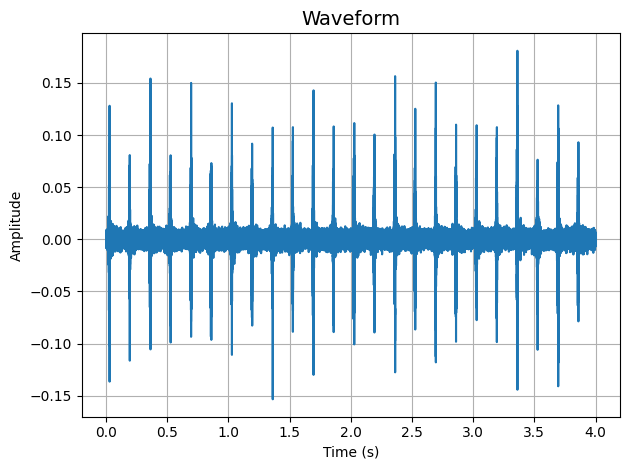

In [183]:
# Load data
samples = load_samples()
selected_sample = 1

sample_info = samples[selected_sample]
file_path = sample_info["path"]
expected_beat_rate = sample_info["expected_beat_rate"]
expected_rate = sample_info["expected_rate"]
tick_range = sample_info["tick_range"]
noise_range = sample_info["noise_range"]

audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True, duration=PROCESSING_INTERVAL_SEC)
print(f"Loaded {file_path} with expected beats: {expected_beat_rate}")

plot_timeseries(audio, sample_rate=SAMPLE_RATE)

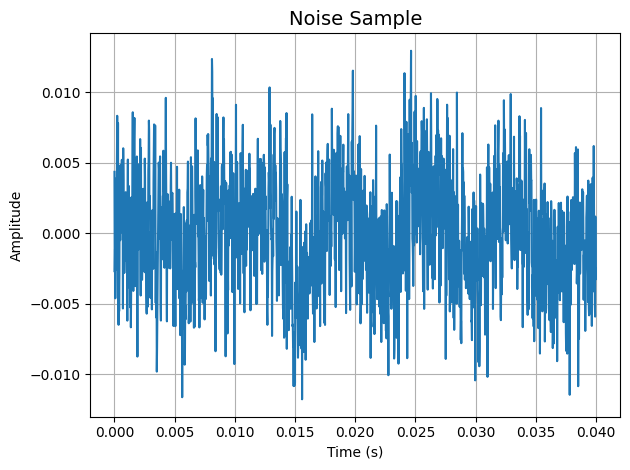

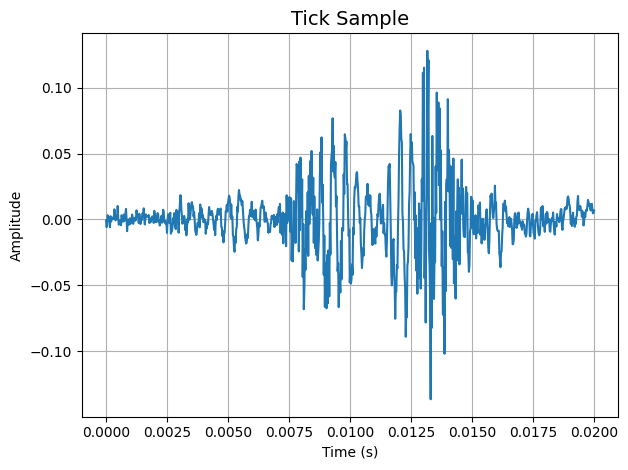

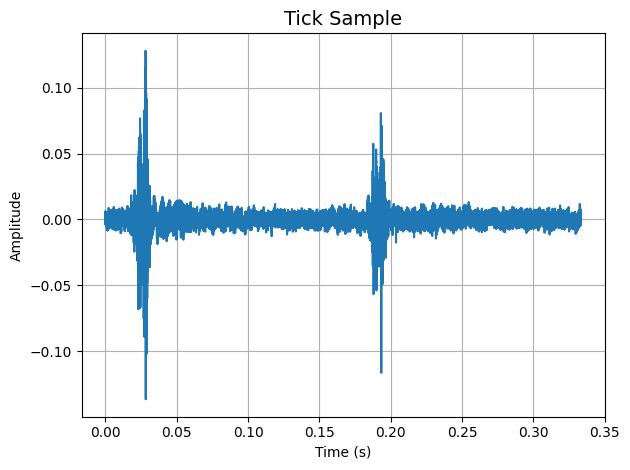

In [184]:
tick_start, tick_end = [int(t * sr) for t in tick_range]
noise_start, noise_end = [int(t * sr) for t in noise_range]
tick_sample = audio[tick_start:tick_end]
noise_sample = audio[noise_start:noise_end]
short_sample = audio[0:int(SAMPLE_RATE/3)]

plot_timeseries(noise_sample, sample_rate=sr, title="Noise Sample")
plot_timeseries(tick_sample, sample_rate=sr, title="Tick Sample")
plot_timeseries(short_sample, sample_rate=sr, title="Tick Sample")

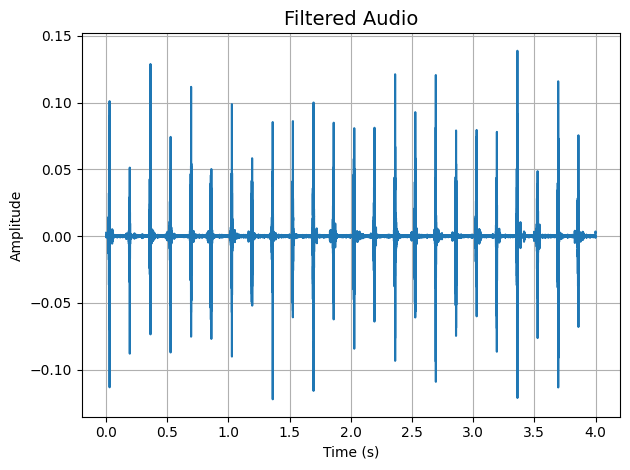

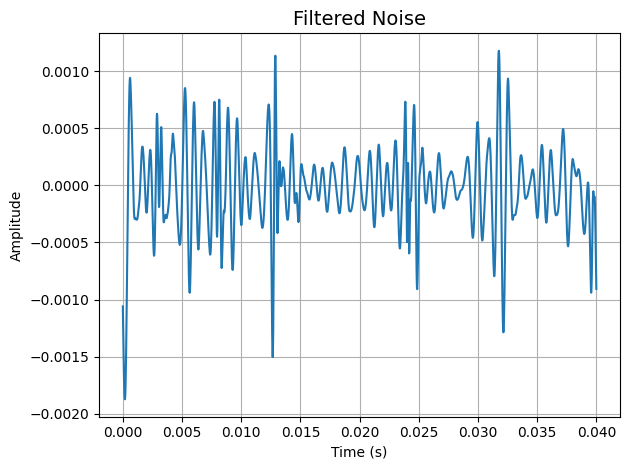

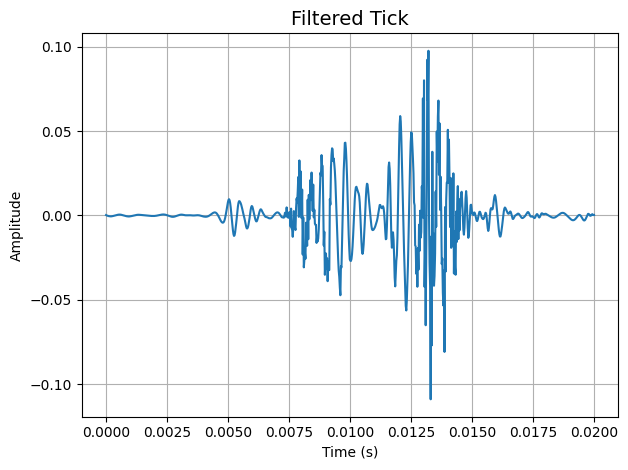

In [185]:
def high_pass_filter(audio, cutoff=1200, sr=SAMPLE_RATE):
    b, a = butter(2, cutoff / (0.5 * sr), btype='high')
    return filtfilt(b, a, audio)

def wavelet_denoise(signal, wavelet="db8", level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level, mode="per")
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs_thresholded = [coeffs[0]] + [pywt.threshold(c, uthresh, mode="soft") for c in coeffs[1:]]
    denoised = pywt.waverec(coeffs_thresholded, wavelet, mode="per")
    return denoised[:len(signal)]

def filter_audio(audio):
    return wavelet_denoise(high_pass_filter(audio))
    
filtered_audio = filter_audio(audio)
plot_timeseries(filtered_audio, sample_rate=SAMPLE_RATE, title="Filtered Audio")

filtered_noise = filter_audio(noise_sample)
plot_timeseries(filtered_noise, sample_rate=SAMPLE_RATE, title="Filtered Noise")

filtered_tick = filter_audio(tick_sample)
plot_timeseries(filtered_tick, sample_rate=SAMPLE_RATE, title="Filtered Tick")

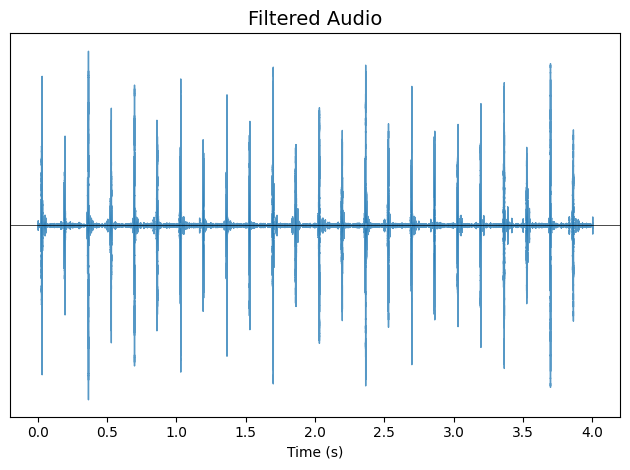

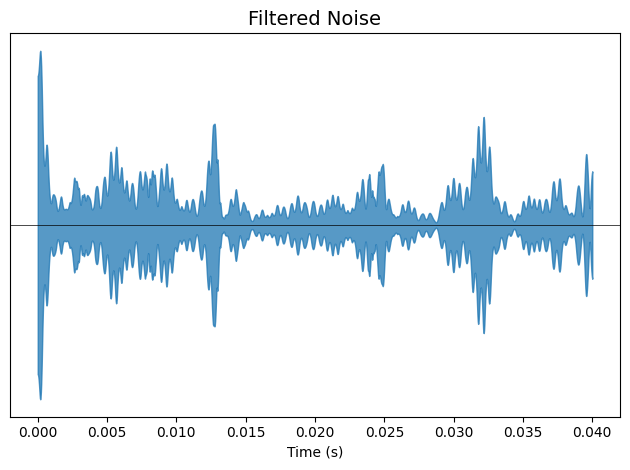

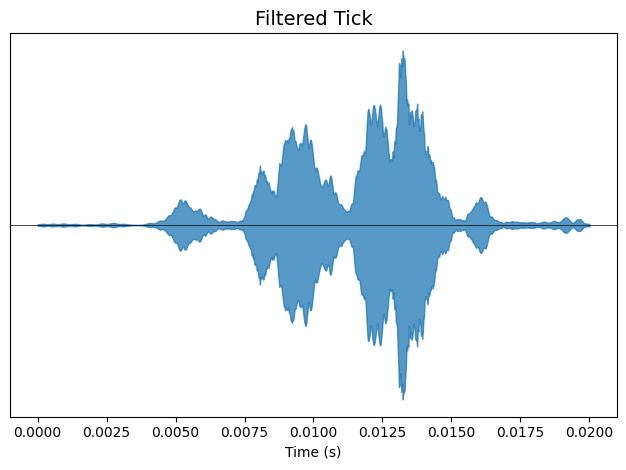

In [186]:
plot_timeseries(filtered_audio, sample_rate=SAMPLE_RATE, title="Filtered Audio", blob=True)
plot_timeseries(filtered_noise,  sample_rate=SAMPLE_RATE, title="Filtered Noise", blob=True)
plot_timeseries(filtered_tick, sample_rate=SAMPLE_RATE, title="Filtered Tick", blob=True)

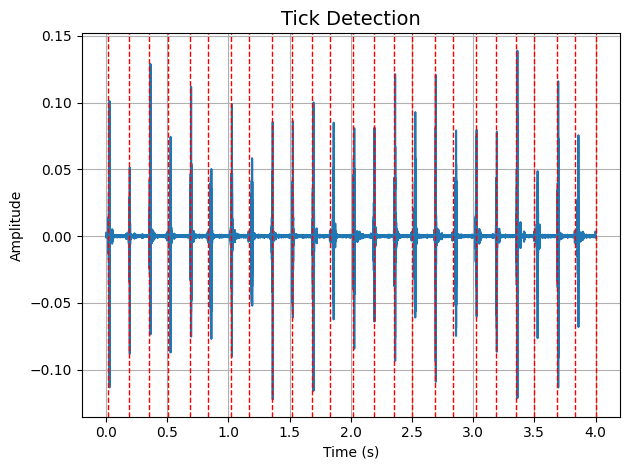

In [187]:
# detecting (t1, t2, ... , tn) correctly
from scipy.signal import find_peaks

def detect_ticks(audio, sample_rate, threshold=0.01, min_spacing_ms=100, dual_threshold=False):
    min_spacing = int((min_spacing_ms / 1000) * sample_rate)
    signal = np.abs(audio)

    tick_times = []
    i = 0
    while i < len(signal):
        if signal[i] > threshold:
            if dual_threshold:
                j = i + 1
                while j < len(signal) and signal[j] > (threshold / 2):
                    j += 1
                tick_times.append(i)
                i = j + min_spacing
            else:
                tick_times.append(i)
                i += min_spacing
        else:
            i += 1

    tick_times_sec = np.array(tick_times) / sample_rate
    return tick_times_sec

tick_times = detect_ticks(filtered_audio, SAMPLE_RATE, threshold=0.003, dual_threshold=True)

plot_timeseries(filtered_audio, SAMPLE_RATE, title="Tick Detection", vlines=list(tick_times))


# Number of ticks to visualize
num_ticks_to_plot = 20
window_before = 0.01
window_after = 0.03

# for idx, t in enumerate(tick_times[:num_ticks_to_plot]):
#     xmin = max(0, t - window_before)
#     xmax = t + window_after
#     plot_timeseries(filtered_audio, SAMPLE_RATE,
#                     title=f"Tick {idx + 1} (around {t:.3f}s)",
#                     vlines=[t],
#                     xmin=xmin, xmax=xmax, blob=True)


In [188]:
intervals = np.diff(tick_times)
print("Avg interval:", np.mean(intervals))


Avg interval: 0.16588907785336357


In [189]:
def compute_rate(tick_times, expected_beat_rate):

    intervals = np.diff(tick_times) 
    expected_interval = 3600 / (expected_beat_rate)
    print("expected_interval:", expected_interval)
    avg_interval = np.mean(intervals)
    print("avg_interval:", avg_interval)
    delta = expected_interval - avg_interval
    print("Delta:", delta)
    rate_sec_per_day = delta / expected_interval * 86400
    print("rate_sec_per_day:", rate_sec_per_day)
    return rate_sec_per_day

rate = compute_rate(tick_times, expected_beat_rate)
print(f"Estimated rate deviation: {rate:.2f} seconds/day")
print(f"Expected beat rate:", expected_rate)


expected_interval: 0.16666666666666666
avg_interval: 0.16588907785336357
Delta: 0.0007775888133030873
rate_sec_per_day: 403.1020408163204
Estimated rate deviation: 403.10 seconds/day
Expected beat rate: 0


In [190]:
print(f"Time of first tick: {tick_times[0]}")
print(f"Time of second tick: {tick_times[-1]}")
print(f"Number of ticks: {tick_times.size}")


Time of first tick: 0.018435374149659865
Time of second tick: 3.9997732426303854
Number of ticks: 25
